# Measuring the AI Learning Content Coverage Gap
## A Case Study of Anthropic Academy

*Research notebook · Data collected 2026-05-20 · [Craftmindship analysis](https://craftmindship.com/analysis/anthropic-academy-skill-formation)*

## 60-Second Summary

**Dataset:** 329 Anthropic product release entries from Claude release notes and Claude Code changelog, plus 18 Anthropic Academy courses from the public Skilljar catalog.

**Window:** April 2025 to May 2026 · **Substance split:** 225 substantive / 104 maintenance

**Metric:** Topic-level coverage gap. No learning platform examined exposes public course update timestamps, so exact update lag cannot be measured. The defensible alternative: *does a public Academy course visibly cover each release topic?*

**Top visible gaps** (substantive releases with no visible Academy coverage):

| Topic | Substantive Releases | Coverage Status |
|-------|---------------------|-----------------|
| permissions/security | 21 | not visible |
| IDE integration | 14 | not visible |
| enterprise/admin | 14 | not visible |
| model support | 16 | partial |

**Well-covered areas:** MCP/tooling (85 substantive releases, 3 dedicated courses) and agentic coding (54, 3 dedicated courses).

**Caveat:** This is a single-vendor case study. It is not a cross-vendor benchmark. OpenAI and Google sources were attempted but encountered access restrictions.

## Why This Notebook Exists

AI products ship faster than course catalogs can track. But "faster" is a feeling — this notebook puts numbers on it.

The goal is narrow: measure what is publicly visible about the gap between Anthropic's product release velocity and Anthropic Academy's public course coverage, using only publicly available data.

This is the evidence layer for [*Anthropic Academy and the Skill Formation Gap*](https://craftmindship.com/analysis/anthropic-academy-skill-formation).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
from pathlib import Path

PROCESSED = Path('../data/processed')
CHARTS = Path('../outputs/charts')
CHARTS.mkdir(parents=True, exist_ok=True)

C = {"blue": "#2563EB", "amber": "#D97706", "slate": "#94A3B8",
     "green": "#16A34A", "yellow": "#EAB308", "red": "#DC2626",
     "blue_l": "#93C5FD"}
STATUS_C = {"covered": C["green"], "partial": C["yellow"], "not visible": C["red"]}

def style(ax, title, xlabel="", ylabel="", note=None):
    ax.set_title(title, fontsize=13, fontweight="bold", pad=14)
    ax.set_xlabel(xlabel, fontsize=10); ax.set_ylabel(ylabel, fontsize=10)
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
    if note:
        ax.annotate(note, xy=(0, -0.16), xycoords="axes fraction",
                    fontsize=7, color="#6B7280", style="italic")

## Data Sources

Data collected 2026-05-20. A prior reconnaissance phase ([00_data_reconnaissance.ipynb](00_data_reconnaissance.ipynb)) assessed all sources.

In [2]:
# Source fetch status
src = pd.read_csv('../data/interim/source_status.csv')
src_display = src[['source_id', 'vendor', 'source_type', 'fetch_status', 'http_status']].copy()
src_display.columns = ['Source', 'Vendor', 'Type', 'Status', 'HTTP']
src_display['HTTP'] = src_display['HTTP'].astype(int)
src_display

,Source,Vendor,Type,Status,HTTP
0,anthropic_release_notes,Anthropic,product_release,success,200
1,claude_code_changelog,Anthropic,product_release,success,200
2,google_gemini_changelog,Google,product_release,success,200
3,openai_changelog,OpenAI,product_release,forbidden,403
4,openai_index,OpenAI,product_release,forbidden,403
5,anthropic_academy,Anthropic,learning_content,success,200
6,openai_academy,OpenAI,learning_content,success,200
7,google_ai_tutorials,Google,learning_content,success,200


**Anthropic** (primary): clean release data + clean course catalog. **OpenAI**: HTTP 403. **Google**: excluded from V1.

## Why Coverage Gap, Not Update Lag

The natural metric would be *days from product release to course update*. This requires course update dates — which **no learning platform examined exposes publicly**.

| Platform | Update date visible? |
|----------|---------------------|
| Anthropic Academy (Skilljar) | No |
| OpenAI Academy | No |
| Google AI Dev | No |

The defensible alternative: **topic-level coverage gap as of the collection date.**

In [3]:
releases = pd.read_csv(PROCESSED / 'anthropic_product_releases.csv')
releases['release_date'] = pd.to_datetime(releases['release_date'])
releases['release_month'] = releases['release_date'].dt.to_period('M')

courses = pd.read_csv(PROCESSED / 'anthropic_learning_content.csv')
gap_summary = pd.read_csv(PROCESSED / 'coverage_gap_summary.csv')
mapping = pd.read_csv(PROCESSED / 'topic_coverage_mapping_reviewed.csv')

subst = (releases['release_substance'] == 'substantive').sum()
maint = len(releases) - subst
print(f"Releases: {len(releases)} total  ({subst} substantive, {maint} maintenance)")
print(f"Academy courses: {len(courses)}")
print(f"Date range: {releases['release_date'].min().date()} to {releases['release_date'].max().date()}")

Releases: 329 total  (225 substantive, 104 maintenance)
Academy courses: 18
Date range: 2025-04-02 to 2026-05-19


## Release Velocity

In [4]:
releases.groupby('product_area').agg(
    total=('title', 'size'),
    substantive=('release_substance', lambda x: (x == 'substantive').sum()),
    maintenance=('release_substance', lambda x: (x == 'maintenance').sum()),
)

,total,substantive,maintenance
product_area,,,
Claude,37,32,5
Claude Code,292,193,99


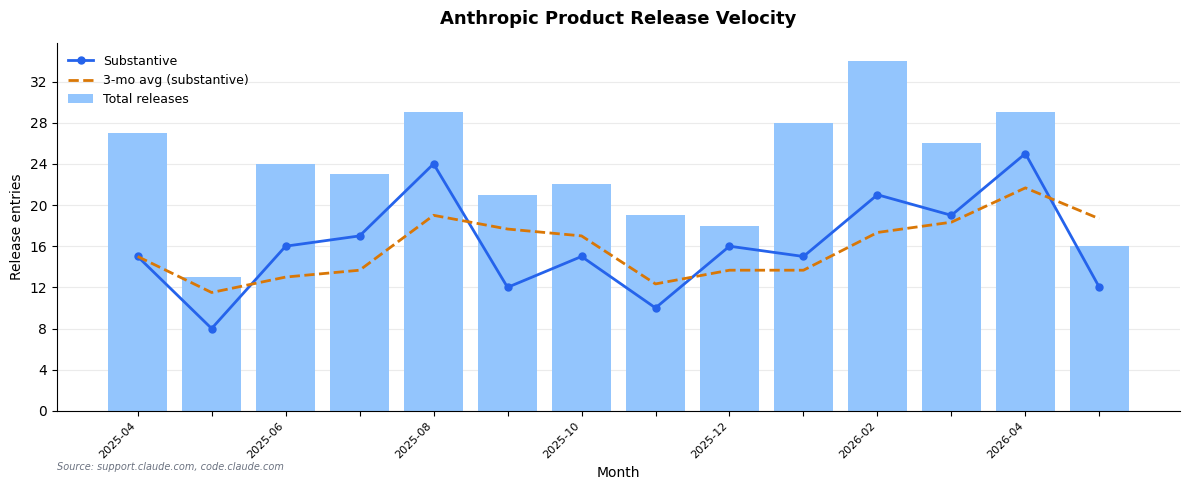

In [5]:
# Chart 1: Velocity over time — bars + substantive line + rolling average
monthly_all = releases.groupby('release_month').size()
monthly_sub = releases[releases['release_substance'] == 'substantive'].groupby('release_month').size()
idx = monthly_all.index.astype(str)
sub_vals = monthly_sub.reindex(monthly_all.index, fill_value=0).values

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(idx)), monthly_all.values, color=C['blue_l'], zorder=2, label='Total releases')
ax.plot(range(len(idx)), sub_vals, color=C['blue'], lw=2, marker='o', ms=5, zorder=3, label='Substantive')
if len(sub_vals) >= 3:
    roll = pd.Series(sub_vals).rolling(3, min_periods=1).mean().values
    ax.plot(range(len(idx)), roll, color=C['amber'], lw=2, ls='--', zorder=3, label='3-mo avg (substantive)')
ax.set_xticks(range(len(idx)))
ax.set_xticklabels(idx, rotation=45, ha='right', fontsize=8)
for i, lb in enumerate(ax.get_xticklabels()):
    if i % 2 != 0: lb.set_visible(False)
ax.legend(loc='upper left', frameon=False, fontsize=9)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.grid(axis='y', alpha=0.25, zorder=0)
style(ax, 'Anthropic Product Release Velocity', 'Month', 'Release entries',
      'Source: support.claude.com, code.claude.com')
plt.tight_layout()
plt.savefig(CHARTS / 'anthropic_release_velocity_monthly.png', dpi=150, bbox_inches='tight')
plt.show()

### Substantive vs maintenance composition

Not all releases create learning-content decay pressure. Bug fixes and docs-only patches do not require course updates.

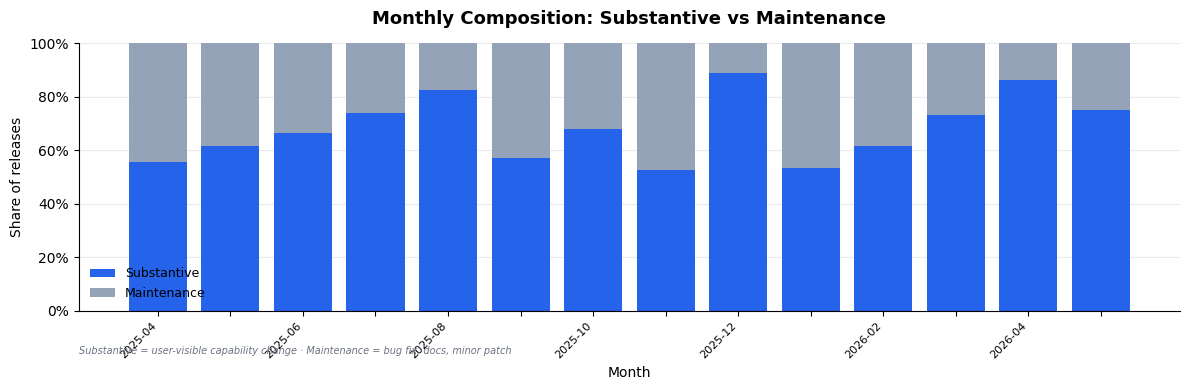

In [6]:
# Chart 2: 100% stacked substance composition
monthly = releases.groupby('release_month').agg(
    subst=('release_substance', lambda x: (x == 'substantive').sum()),
    maint=('release_substance', lambda x: (x == 'maintenance').sum()))
monthly.index = monthly.index.astype(str)
totals = monthly['subst'] + monthly['maint']
pct_sub = (monthly['subst'] / totals * 100).values
pct_mnt = (monthly['maint'] / totals * 100).values

fig, ax = plt.subplots(figsize=(12, 4))
x = range(len(monthly))
ax.bar(x, pct_sub, color=C['blue'], label='Substantive', zorder=2)
ax.bar(x, pct_mnt, bottom=pct_sub, color=C['slate'], label='Maintenance', zorder=2)
ax.set_xticks(list(x))
ax.set_xticklabels(monthly.index, rotation=45, ha='right', fontsize=8)
for i, lb in enumerate(ax.get_xticklabels()):
    if i % 2 != 0: lb.set_visible(False)
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(loc='lower left', frameon=False, fontsize=9)
ax.grid(axis='y', alpha=0.25, zorder=0)
style(ax, 'Monthly Composition: Substantive vs Maintenance', 'Month', 'Share of releases',
      'Substantive = user-visible capability change · Maintenance = bug fix, docs, minor patch')
plt.tight_layout()
plt.savefig(CHARTS / 'anthropic_release_velocity_substance.png', dpi=150, bbox_inches='tight')
plt.show()

## Release Topic Mix

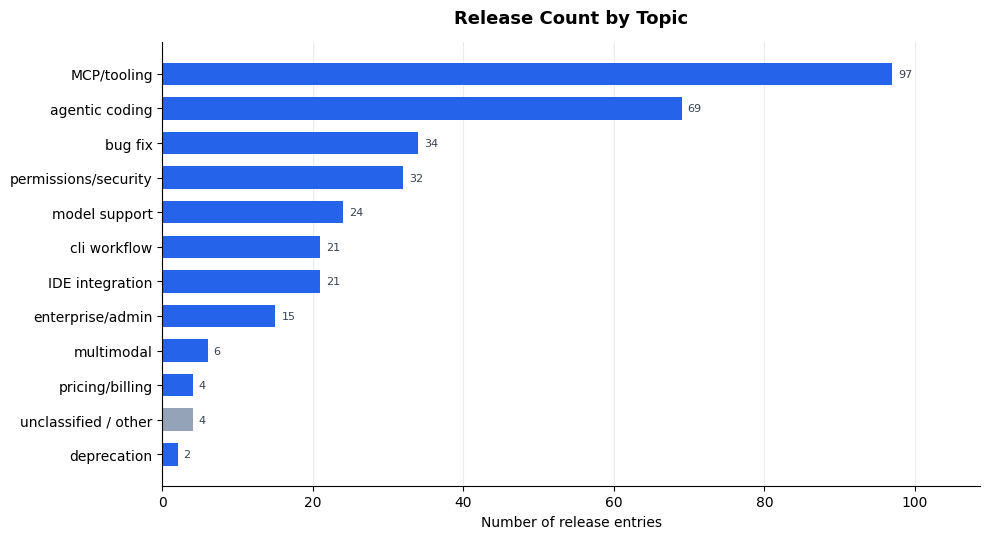

In [7]:
# Chart 3: Topic distribution — horizontal bars
tc = releases.groupby('topic_subcategory').size().sort_values(ascending=True)
tc.index = [('unclassified / other' if t == 'other' else t) for t in tc.index]

fig, ax = plt.subplots(figsize=(10, 5.5))
colors = [C['slate'] if 'unclassified' in t else C['blue'] for t in tc.index]
bars = ax.barh(tc.index, tc.values, color=colors, zorder=2, height=0.65)
for bar, val in zip(bars, tc.values):
    ax.text(val + 0.8, bar.get_y() + bar.get_height() / 2, str(val), va='center', fontsize=8, color='#374151')
ax.grid(axis='x', alpha=0.25, zorder=0)
ax.set_xlim(right=tc.max() * 1.12)
style(ax, 'Release Count by Topic', 'Number of release entries', '')
plt.tight_layout()
plt.savefig(CHARTS / 'anthropic_release_topics.png', dpi=150, bbox_inches='tight')
plt.show()

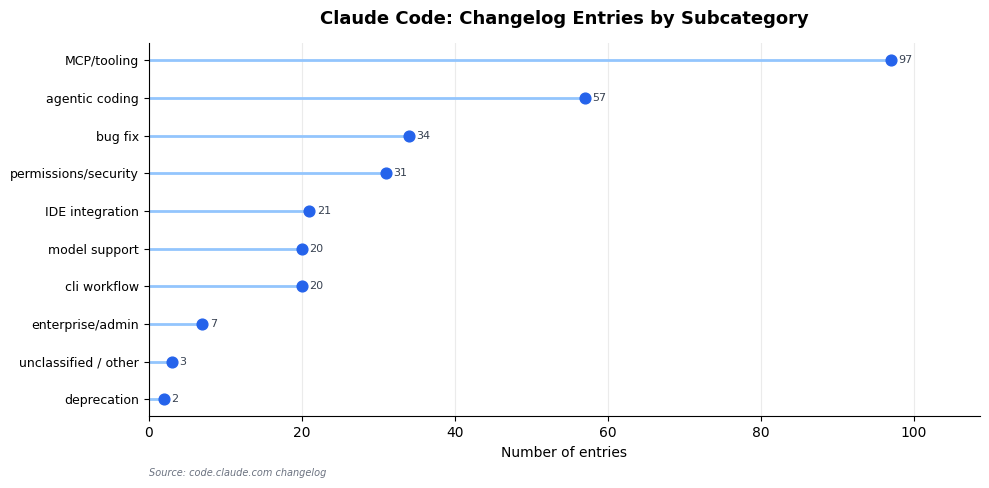

In [8]:
# Chart 4: Claude Code subcategories — lollipop plot
cc = releases[releases['product_area'] == 'Claude Code']
sc = cc.groupby('topic_subcategory').size().sort_values(ascending=True)
sc.index = [('unclassified / other' if t == 'other' else t) for t in sc.index]

fig, ax = plt.subplots(figsize=(10, 5))
y = range(len(sc))
ax.hlines(y, 0, sc.values, color=C['blue_l'], lw=2, zorder=2)
ax.scatter(sc.values, y, color=C['blue'], s=60, zorder=3)
for i, (val, label) in enumerate(zip(sc.values, sc.index)):
    ax.text(val + 1, i, str(val), va='center', fontsize=8, color='#374151')
ax.set_yticks(list(y)); ax.set_yticklabels(sc.index, fontsize=9)
ax.set_xlim(left=0, right=sc.max() * 1.12)
ax.grid(axis='x', alpha=0.25, zorder=0)
style(ax, 'Claude Code: Changelog Entries by Subcategory', 'Number of entries', '',
      'Source: code.claude.com changelog')
plt.tight_layout()
plt.savefig(CHARTS / 'anthropic_claude_code_subcategories.png', dpi=150, bbox_inches='tight')
plt.show()

## Anthropic Academy Course Catalog

18 public courses on Skilljar. No course update timestamps are publicly visible.

Full catalog: `outputs/tables/academy_course_catalog_clean.csv`

In [9]:
# Build course-to-topic lookup from the coverage mapping
_ct = {}
for _, _m in mapping.iterrows():
    _cs = str(_m['related_academy_courses']) if pd.notna(_m['related_academy_courses']) else ''
    for _c in _cs.split('; '):
        _c = _c.strip()
        if _c and _c != 'nan':
            _ct.setdefault(_c, set()).add(_m['topic_subcategory'])

cat = courses[['title', 'description']].copy()
cat['description'] = cat['description'].str[:120]
cat['topics_covered'] = cat['title'].map(lambda t: ', '.join(sorted(_ct.get(t, set()))) or '—')
cat.columns = ['Course', 'Description', 'Topics Covered']
cat

,Course,Description,Topics Covered
0,Claude 101,Learn how to use Claude for everyday work task...,model support
1,Claude Code 101,Learn how to use Claude Code effectively in yo...,"cli workflow, model support"
2,Introduction to Claude Cowork,Learn to work alongside Claude on your real fi...,"MCP/tooling, agentic coding, model support"
3,Claude Code in Action,Integrate Claude Code into your development wo...,"cli workflow, model support"
4,AI Fluency: Framework & Foundations,Learn to collaborate with AI systems effective...,—
5,Building with the Claude API,This comprehensive course covers the full spec...,model support
6,Introduction to Model Context Protocol,Learn to build Model Context Protocol servers ...,"MCP/tooling, model support"
7,AI Fluency for educators,"This course empowers faculty, instructional de...",—
8,AI Fluency for students,This course empowers students to develop AI Fl...,—
9,Model Context Protocol: Advanced Topics,Discover advanced Model Context Protocol imple...,"MCP/tooling, model support"


## Course × Topic Coverage Matrix

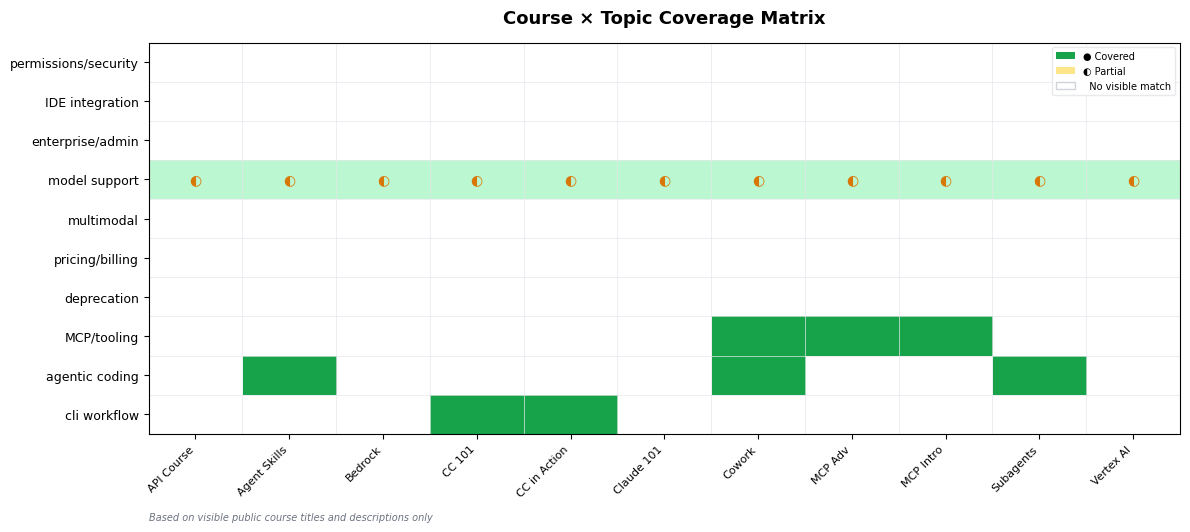

In [10]:
# Chart 6: Coverage matrix — topic rows × course columns
topic_courses = {}
course_set = set()
for _, m in mapping.iterrows():
    cs = str(m['related_academy_courses']) if pd.notna(m['related_academy_courses']) else ''
    subcat = m['topic_subcategory']
    status = m['coverage_status']
    matched = [c.strip() for c in cs.split(';') if c.strip() and c.strip() != 'nan']
    topic_courses[subcat] = {'courses': matched, 'status': status}
    course_set.update(matched)

short = {"Claude 101": "Claude 101", "Claude Code 101": "CC 101",
         "Claude Code in Action": "CC in Action", "Introduction to Claude Cowork": "Cowork",
         "Building with the Claude API": "API Course",
         "Introduction to Model Context Protocol": "MCP Intro",
         "Model Context Protocol: Advanced Topics": "MCP Adv",
         "Claude with Amazon Bedrock": "Bedrock",
         "Claude with Google Cloud's Vertex AI": "Vertex AI",
         "Introduction to agent skills": "Agent Skills",
         "Introduction to subagents": "Subagents"}
course_list = sorted(course_set, key=lambda c: short.get(c, c))
course_labels = [short.get(c, c[:15]) for c in course_list]

gap_ordered = gap_summary.copy()
gap_ordered['_s'] = pd.to_numeric(gap_ordered['gap_score'], errors='coerce').fillna(-1)
gap_ordered = gap_ordered.sort_values('_s', ascending=False)
topic_list = [t for t in gap_ordered['topic_subcategory'] if t not in ('bug fix', 'other')]

mat = np.zeros((len(topic_list), len(course_list)))
for i, t in enumerate(topic_list):
    info = topic_courses.get(t, {'courses': [], 'status': 'not visible'})
    for j, c in enumerate(course_list):
        if c in info['courses']:
            mat[i, j] = 1.0 if info['status'] == 'covered' else 0.5

fig, ax = plt.subplots(figsize=(12, 5.5))
cmap = ListedColormap(['#FFFFFF', '#FEF3C7', '#BBF7D0', '#16A34A'])
norm = BoundaryNorm([0, 0.1, 0.4, 0.8, 1.1], cmap.N)
ax.imshow(mat, cmap=cmap, norm=norm, aspect='auto')
ax.set_xticks(range(len(course_labels)))
ax.set_xticklabels(course_labels, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(topic_list)))
ax.set_yticklabels(topic_list, fontsize=9)
for i in range(len(topic_list)):
    for j in range(len(course_list)):
        v = mat[i, j]
        if v >= 0.8: ax.text(j, i, '●', ha='center', va='center', fontsize=10, color=C['green'])
        elif v >= 0.4: ax.text(j, i, '◐', ha='center', va='center', fontsize=10, color=C['amber'])
ax.set_xticks([x - 0.5 for x in range(len(course_labels) + 1)], minor=True)
ax.set_yticks([y - 0.5 for y in range(len(topic_list) + 1)], minor=True)
ax.grid(which='minor', color='#E5E7EB', lw=0.5)
ax.tick_params(which='minor', bottom=False, left=False)
patches = [mpatches.Patch(facecolor=C['green'], label='● Covered'),
           mpatches.Patch(facecolor='#FDE68A', label='◐ Partial'),
           mpatches.Patch(facecolor='white', edgecolor='#D1D5DB', label='  No visible match')]
ax.legend(handles=patches, loc='upper right', fontsize=7, frameon=True, framealpha=0.9, edgecolor='#E5E7EB')
ax.set_title('Course × Topic Coverage Matrix', fontsize=13, fontweight='bold', pad=14)
ax.annotate('Based on visible public course titles and descriptions only',
            xy=(0, -0.22), xycoords='axes fraction', fontsize=7, color='#6B7280', style='italic')
plt.tight_layout()
plt.savefig(CHARTS / 'anthropic_course_topic_coverage_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

The matrix shows that Academy coverage concentrates on MCP/tooling, agentic coding, and CLI workflow — the areas Anthropic has invested dedicated courses in. Permissions/security, IDE integration, and enterprise/admin have no visible course coverage despite significant release activity.

## Coverage Gap Findings

Coverage classification rules:
- **Covered:** Course title or description explicitly mentions the topic.
- **Partial:** Thematic overlap but no dedicated course.
- **Not visible:** No course text visibly mentions the topic.

Matching evidence: `data/processed/topic_coverage_mapping_reviewed.csv`

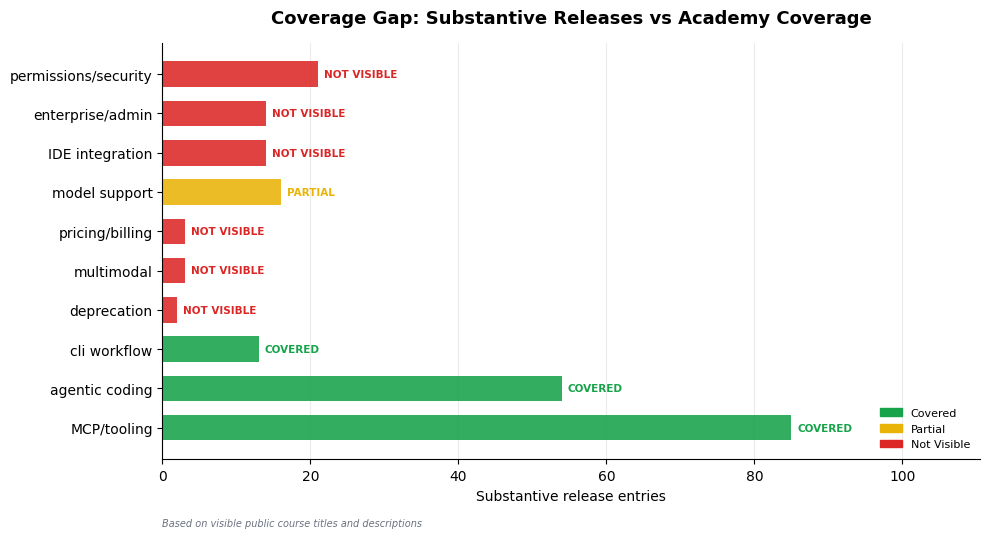

In [11]:
# Chart 5: Coverage gap
df = gap_summary.copy()
df['gap_num'] = pd.to_numeric(df['gap_score'], errors='coerce').fillna(0)
df = df[(df['substantive_releases'] > 0) & (~df['topic_subcategory'].isin(['bug fix', 'other']))].copy()
df = df.sort_values('gap_num', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5.5))
bar_colors = [STATUS_C.get(s, C['slate']) for s in df['coverage_status']]
bars = ax.barh(df['topic_subcategory'], df['substantive_releases'],
               color=bar_colors, zorder=2, height=0.65, alpha=0.88)
for i, (_, row) in enumerate(df.iterrows()):
    status = row['coverage_status']
    color = STATUS_C.get(status, '#6B7280')
    ax.text(row['substantive_releases'] + 0.8, i, status.upper(),
            va='center', fontsize=7.5, color=color, fontweight='bold')
patches = [mpatches.Patch(color=STATUS_C[s], label=s.title()) for s in ['covered', 'partial', 'not visible']]
ax.legend(handles=patches, loc='lower right', frameon=False, fontsize=8)
ax.grid(axis='x', alpha=0.25, zorder=0)
ax.set_xlim(right=df['substantive_releases'].max() * 1.3)
style(ax, 'Coverage Gap: Substantive Releases vs Academy Coverage',
      'Substantive release entries', '',
      'Based on visible public course titles and descriptions')
plt.tight_layout()
plt.savefig(CHARTS / 'anthropic_coverage_gap_by_topic.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Gap score table
gap_display = gap_summary[['topic_subcategory', 'total_releases', 'substantive_releases',
                            'breaking_changes', 'courses_covering_count',
                            'coverage_status', 'gap_score']].copy()
gap_display.columns = ['Topic', 'Total', 'Substantive', 'Breaking', 'Courses', 'Status', 'Gap Score']
gap_display = gap_display.sort_values('Gap Score', ascending=False,
                                      key=lambda x: pd.to_numeric(x, errors='coerce').fillna(-1))
gap_display

,Topic,Total,Substantive,Breaking,Courses,Status,Gap Score
0,permissions/security,32,21,0,0,not visible,21
1,IDE integration,21,14,0,0,not visible,14
2,enterprise/admin,15,14,0,0,not visible,14
3,model support,24,16,0,11,partial,8
4,multimodal,6,3,0,0,not visible,3
5,pricing/billing,4,3,0,0,not visible,3
6,deprecation,2,2,2,0,not visible,2
7,MCP/tooling,97,85,0,3,covered,0
8,agentic coding,69,54,0,3,covered,0
9,bug fix,34,0,1,0,not visible,0


### Key observations

1. **MCP/tooling** and **agentic coding** are the highest-velocity areas and are **covered** by dedicated courses (MCP intro + advanced, Cowork, agent skills, subagents).

2. **Permissions/security** (21 substantive releases) is the largest **uncovered** topic — no Academy course visibly addresses permissions, security, or access control.

3. **IDE integration** (14) and **enterprise/admin** (14) are also uncovered — VS Code/JetBrains features and SSO/workspace management have no visible dedicated course.

4. **Model support** (16) is **partially** covered — the API course mentions "Anthropic models" but no course is dedicated to model selection or capabilities comparison.

## What This Proves and Does Not Prove

| This notebook supports | This notebook does NOT support |
|----------------------|-------------------------------|
| Anthropic public product surfaces changed frequently over the observed period | Any claim about Anthropic's internal education efforts |
| Claude Code creates a high-velocity learning surface | Any claim that Anthropic Academy is "bad" or "neglected" |
| Some fast-moving topics are not visibly covered in the public catalog | Any claim about course quality or depth |
| Course update timestamps are not publicly visible | Exact content decay days or update lag |
| Topic-level coverage gap is a defensible V1 metric | Any comparative claim across AI vendors |

## Implications for Living Learning Infrastructure

1. **Release velocity outpaces static catalogs.** Even with 18 courses, fast-moving subcategories (permissions, IDE, enterprise admin) are not visibly covered.
2. **The substance split matters.** Raw release counts overstate learning load. Filtering to substantive releases gives a more honest picture.
3. **Coverage ≠ currency.** Without update timestamps, we cannot distinguish "covered and current" from "covered but stale."
4. **Living learning infrastructure** — continuously updated content tied to release pipelines — may be more appropriate for high-velocity product surfaces.

These are directional observations from a single vendor's public surface, not general conclusions.

## Limitations

1. **Single vendor.** Anthropic-only case study.
2. **No course update timestamps.** Metric is coverage gap, not update lag.
3. **Title/description matching only.** Courses may cover topics not in visible public text.
4. **Keyword-based classification.** Substance audit showed ~7% false-positive rate.
5. **Snapshot.** Data collected 2026-05-20.

## Next Research Steps

1. **Multi-vendor comparison.** Retry OpenAI with Playwright or manual methods.
2. **Sub-item categorization.** Classify Claude Code at the bullet-point level.
3. **Temporal tracking.** Re-run periodically to detect catalog changes.
4. **Community learning proxy.** Stack Overflow, GitHub Discussions, or Discord as informal coverage signals.

---

*Notebook generated 2026-05-20 · Source: [github.com/lvltcode/anthropic-academy-coverage-gap](https://github.com/lvltcode/anthropic-academy-coverage-gap)*